Exp 6:

 Credit Risk Assessment: Build a credit scoring model to assess
the creditworthiness of applicants using historical financial data and
perform comparative analysis (Logistic Regression, Random Forest,
XGBoost)

In [2]:
# import Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score,recall_score,precision_score,f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [3]:
#Load dataset
data = pd.read_csv("/content/drive/MyDrive/python-ml-lab/exp5_6_7_8/credit_risk_assessment_500_samples.csv")

# Display first 5 rows
data.head(5)


,Applicant_ID,Age,Annual_Income,Employment_Years,Credit_Score,Loan_Amount,Loan_Term_Months,Existing_Loans_Count,Debt_to_Income_Ratio,Late_Payments_Last_2Yrs,Credit_Risk
0,1,59,153267,28,818,196649,12,2,0.68,0,High
1,2,49,232745,0,436,175354,60,0,0.23,5,High
2,3,35,974945,19,797,662297,48,3,0.54,0,Medium
3,4,63,307164,29,776,831725,48,0,0.56,4,High
4,5,28,685626,6,893,498625,60,3,0.66,8,High


In [4]:
data.shape

(500, 11)

In [5]:
# Preprocessing
# Drop Applicant_ID (not useful for prediction)
data = data.drop(columns=['Applicant_ID'], errors='ignore')

# Encode target variable 'Credit_Risk'
# Using LabelEncoder: High=0, Low=1, Medium=2 (alphabetical by default)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data["Credit_Risk"] = le.fit_transform(data["Credit_Risk"])

In [6]:
# Features and target
X = data.drop("Credit_Risk", axis=1)
y = data["Credit_Risk"]

In [7]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# --- Create All Models ---
LR = LogisticRegression(max_iter=1000)
LR.fit(X_train, y_train)

RF = RandomForestClassifier(n_estimators=100, random_state=42)
RF.fit(X_train, y_train)

XGB = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
XGB.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:40:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [9]:
# ---  Accuracy Scores ---
lr_acc = accuracy_score(y_test, LR.predict(X_test))
rf_acc = accuracy_score(y_test, RF.predict(X_test))
xgb_acc = accuracy_score(y_test, XGB.predict(X_test))

print(f"Logistic Regression Accuracy: {lr_acc}")
print(f"Random Forest Accuracy: {rf_acc}")
print(f"XGBoost Accuracy: {xgb_acc}")

Logistic Regression Accuracy: 0.85
Random Forest Accuracy: 0.98
XGBoost Accuracy: 1.0


In [10]:
# --- Precision Scores ---
lr_precision = precision_score(y_test, LR.predict(X_test), average='weighted')
rf_precision = precision_score(y_test, RF.predict(X_test), average='weighted')
xgb_precision = precision_score(y_test, XGB.predict(X_test), average='weighted')

print(f"LR Precision:  {lr_precision:.4f}")
print(f"RF Precision:  {rf_precision:.4f}")
print(f"XGB Precision: {xgb_precision:.4f}")

LR Precision:  0.8474
RF Precision:  0.9810
XGB Precision: 1.0000


In [11]:
# --- Recall Scores ---
lr_recall = recall_score(y_test, LR.predict(X_test), average='weighted')
rf_recall = recall_score(y_test, RF.predict(X_test), average='weighted')
xgb_recall = recall_score(y_test, XGB.predict(X_test), average='weighted')

print(f"\nLR Recall:     {lr_recall:.4f}")
print(f"RF Recall:     {rf_recall:.4f}")
print(f"XGB Recall:    {xgb_recall:.4f}")


LR Recall:     0.8500
RF Recall:     0.9800
XGB Recall:    1.0000


In [12]:
# --- ROC-AUC Scores ---
# We use predict_proba for ROC-AUC to measure the model's confidence
lr_auc = roc_auc_score(y_test, LR.predict_proba(X_test), multi_class='ovr')
rf_auc = roc_auc_score(y_test, RF.predict_proba(X_test), multi_class='ovr')
xgb_auc = roc_auc_score(y_test, XGB.predict_proba(X_test), multi_class='ovr')

print(f"\nLR ROC-AUC:    {lr_auc:.4f}")
print(f"RF ROC-AUC:    {rf_auc:.4f}")
print(f"XGB ROC-AUC:   {xgb_auc:.4f}")


LR ROC-AUC:    0.9498
RF ROC-AUC:    0.9994
XGB ROC-AUC:   1.0000


In [13]:
# ---  F1 Scores ---
# F1 Score is the harmonic mean of Precision and Recall.
# It is especially useful if you have an uneven class distribution.
lr_f1 = f1_score(y_test, LR.predict(X_test), average='weighted')
rf_f1 = f1_score(y_test, RF.predict(X_test), average='weighted')
xgb_f1 = f1_score(y_test, XGB.predict(X_test), average='weighted')

print(f"LR F1-Score:  {lr_f1:.4f}")
print(f"RF F1-Score:  {rf_f1:.4f}")
print(f"XGB F1-Score: {xgb_f1:.4f}")

LR F1-Score:  0.8472
RF F1-Score:  0.9778
XGB F1-Score: 1.0000


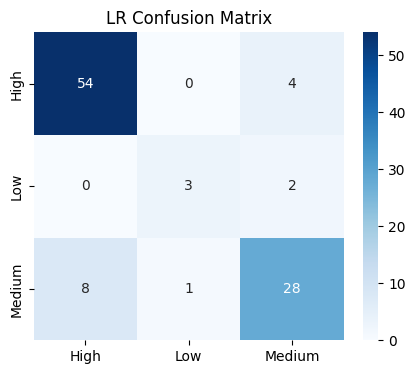

In [14]:
# --- Confusion Matrices ---

# Logistic Regression Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, LR.predict(X_test)), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("LR Confusion Matrix")
plt.show()

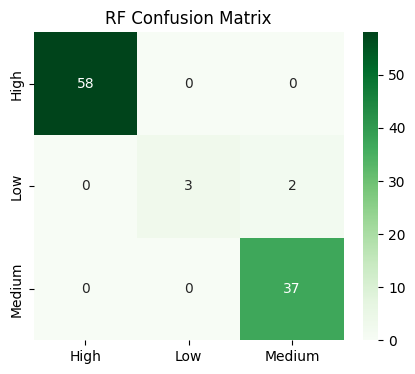

In [15]:
# Random Forest Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, RF.predict(X_test)), annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("RF Confusion Matrix")
plt.show()

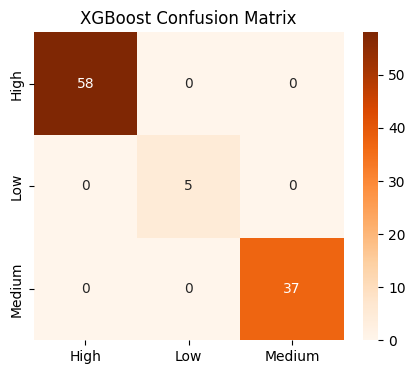

In [16]:
# XGBoost Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, XGB.predict(X_test)), annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("XGBoost Confusion Matrix")
plt.show()

In [17]:
# Saving the model
import pickle
import os

# Define a directory to save models
model_dir = 'trained_models'
os.makedirs(model_dir, exist_ok=True)

# Save Logistic Regression model
with open(os.path.join(model_dir, 'logistic_regression_model.pkl'), 'wb') as f:
    pickle.dump(LR, f)
print(f"Logistic Regression model saved to {model_dir}/logistic_regression_model.pkl")

# Save Random Forest model
with open(os.path.join(model_dir, 'random_forest_model.pkl'), 'wb') as f:
    pickle.dump(RF, f)
print(f"Random Forest model saved to {model_dir}/random_forest_model.pkl")

# Save XGBoost model
with open(os.path.join(model_dir, 'xgboost_model.pkl'), 'wb') as f:
    pickle.dump(XGB, f)
print(f"XGBoost model saved to {model_dir}/xgboost_model.pkl")

Logistic Regression model saved to trained_models/logistic_regression_model.pkl
Random Forest model saved to trained_models/random_forest_model.pkl
XGBoost model saved to trained_models/xgboost_model.pkl
